In [2]:
# ============================================================
# AIMS-TBI 2026 Preprocessing
# Phase 0 - Setup
# ============================================================

import os
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import SimpleITK as sitk

from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/viiishnu/aims-challengefiles/ChallengeFiles"

WORKING_DIR = "/kaggle/working/preprocessing"

METADATA_DIR = os.path.join(WORKING_DIR, "metadata")
LOG_DIR = os.path.join(WORKING_DIR, "logs")
PROCESSED_DIR = os.path.join(WORKING_DIR, "Processed_Dataset")

# Create folders

os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("="*60)
print("AIMS-TBI PREPROCESSING SETUP")
print("="*60)

print("\nDataset Exists :", os.path.exists(DATASET_PATH))

print("\nDataset Path")
print(DATASET_PATH)

print("\nTotal Files :", len(os.listdir(DATASET_PATH)))

print("\nWorking Directory")
print(WORKING_DIR)

print("\nSetup Completed Successfully.")

AIMS-TBI PREPROCESSING SETUP

Dataset Exists : True

Dataset Path
/kaggle/input/datasets/viiishnu/aims-challengefiles/ChallengeFiles

Total Files : 1815

Working Directory
/kaggle/working/preprocessing

Setup Completed Successfully.


In [6]:
# ============================================================
# Phase 1 - Dataset Indexing (Corrected)
# ============================================================

import os
import pandas as pd

files = os.listdir(DATASET_PATH)

records = {}

for f in files:

    if not f.startswith("scan_"):
        continue

    patient = "_".join(f.split("_")[:2])

    if patient not in records:

        records[patient] = {

            "PatientID": patient,
            "T1": "",
            "dMRI": "",
            "Lesion": "",
            "bval": "",
            "bvec": ""

        }

    if "_T1" in f:
        records[patient]["T1"] = f

    elif "_dMRI" in f:
        records[patient]["dMRI"] = f

    elif "_Lesion" in f:
        records[patient]["Lesion"] = f

    elif "_bval" in f:
        records[patient]["bval"] = f

    elif "_bvec" in f:
        records[patient]["bvec"] = f

# -------------------------------------------------------
# KEEP ONLY PATIENTS HAVING T1 OR LESION
# -------------------------------------------------------

manifest = pd.DataFrame(records.values())

manifest = manifest[
    (manifest["T1"] != "") |
    (manifest["Lesion"] != "")
]

manifest = manifest.sort_values("PatientID").reset_index(drop=True)

manifest.to_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv"),
    index=False
)

print("="*60)
print("DATASET INDEXING COMPLETED")
print("="*60)

print()

print("Patients Found :", len(manifest))

print()

print("Availability")

for col in ["T1","dMRI","Lesion","bval","bvec"]:

    print(f"{col:<8}: {(manifest[col] != '').sum()}")

print()

display(manifest.head())

DATASET INDEXING COMPLETED

Patients Found : 552

Availability
T1      : 552
dMRI    : 229
Lesion  : 552
bval    : 229
bvec    : 229



,PatientID,T1,dMRI,Lesion,bval,bvec
0,scan_0001,scan_0001_T1.nii,,scan_0001_Lesion.nii,,
1,scan_0004,scan_0004_T1.nii,scan_0004_dMRI.nii,scan_0004_Lesion.nii,scan_0004_bval.txt,scan_0004_bvec.txt
2,scan_0007,scan_0007_T1.nii,,scan_0007_Lesion.nii,,
3,scan_0016,scan_0016_T1.nii,scan_0016_dMRI.nii,scan_0016_Lesion.nii,scan_0016_bval.txt,scan_0016_bvec.txt
4,scan_0017,scan_0017_T1.nii,,scan_0017_Lesion.nii,,


In [7]:
# ============================================================
# Phase 2 - Dataset Validation
# ============================================================

import os
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

validation_rows = []
failed_rows = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    patient = row["PatientID"]

    for modality in ["T1", "Lesion"]:

        filename = row[modality]

        if pd.isna(filename) or filename == "":

            failed_rows.append({
                "PatientID": patient,
                "Modality": modality,
                "Reason": "Missing File"
            })

            continue

        filepath = os.path.join(DATASET_PATH, filename)

        if not os.path.exists(filepath):

            failed_rows.append({
                "PatientID": patient,
                "Modality": modality,
                "Reason": "File Not Found"
            })

            continue

        try:

            image = sitk.ReadImage(filepath)

            validation_rows.append({

                "PatientID": patient,

                "Modality": modality,

                "Filename": filename,

                "Dimension": image.GetDimension(),

                "Size": image.GetSize(),

                "Spacing": image.GetSpacing(),

                "Origin": image.GetOrigin(),

                "Direction": image.GetDirection(),

                "PixelType": image.GetPixelIDTypeAsString()

            })

        except Exception as e:

            failed_rows.append({

                "PatientID": patient,

                "Modality": modality,

                "Reason": str(e)

            })

validation = pd.DataFrame(validation_rows)
failed = pd.DataFrame(failed_rows)

validation.to_csv(
    os.path.join(METADATA_DIR, "validation_report.csv"),
    index=False
)

failed.to_csv(
    os.path.join(METADATA_DIR, "failed_cases.csv"),
    index=False
)

print("="*60)
print("VALIDATION COMPLETED")
print("="*60)

print(f"\nPatients              : {len(manifest)}")
print(f"Valid Images          : {len(validation)}")
print(f"Failed Images         : {len(failed)}")

print("\nModalities")

print(validation["Modality"].value_counts())

print("\nValidation report saved to")

print(os.path.join(METADATA_DIR, "validation_report.csv"))

print("\nFailed report saved to")

print(os.path.join(METADATA_DIR, "failed_cases.csv"))

if len(failed):

    print("\nFirst Failed Cases")

    display(failed.head())

else:

    print("\nNo failed cases found.")

100%|██████████| 552/552 [05:59<00:00,  1.54it/s]

VALIDATION COMPLETED

Patients              : 552
Valid Images          : 1104
Failed Images         : 0

Modalities
Modality
T1        552
Lesion    552
Name: count, dtype: int64

Validation report saved to
/kaggle/working/preprocessing/metadata/validation_report.csv

Failed report saved to
/kaggle/working/preprocessing/metadata/failed_cases.csv

No failed cases found.


In [8]:
# ============================================================
# Phase 3 - Dataset Analysis
# ============================================================

import os
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

rows = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    patient = row["PatientID"]

    for modality in ["T1", "Lesion"]:

        filename = row[modality]

        image = sitk.ReadImage(
            os.path.join(DATASET_PATH, filename)
        )

        rows.append({

            "PatientID": patient,

            "Modality": modality,

            "Dimension": image.GetDimension(),

            "Size": image.GetSize(),

            "Spacing": image.GetSpacing(),

            "Origin": image.GetOrigin(),

            "Direction": image.GetDirection(),

            "PixelType": image.GetPixelIDTypeAsString()

        })

analysis = pd.DataFrame(rows)

analysis.to_csv(
    os.path.join(METADATA_DIR, "geometry_report.csv"),
    index=False
)

print("="*60)
print("DATASET ANALYSIS")
print("="*60)

print("\n1. Image Dimensions")
print(analysis["Dimension"].value_counts())

print("\n2. Pixel Types")
print(analysis["PixelType"].value_counts())

print("\n3. Unique Spacing Values")
print(analysis["Spacing"].value_counts())

print("\nTotal Unique Spacing:",
      analysis["Spacing"].nunique())

print("\n4. Unique Directions")

print(
    analysis["Direction"]
    .value_counts()
    .head(10)
)

print("\nTotal Unique Directions:",
      analysis["Direction"].nunique())

# ------------------------------------------------------
# Find spacing outlier patients
# ------------------------------------------------------

spacing_outliers = analysis[
    analysis["Spacing"] != (1.0, 1.0, 1.0)
][["PatientID", "Spacing"]].drop_duplicates()

print("\n5. Patients Requiring Resampling")

display(spacing_outliers)

100%|██████████| 552/552 [05:50<00:00,  1.57it/s]

DATASET ANALYSIS

1. Image Dimensions
Dimension
3    1104
Name: count, dtype: int64

2. Pixel Types
PixelType
32-bit float               550
16-bit unsigned integer    499
32-bit signed integer       53
16-bit signed integer        2
Name: count, dtype: int64

3. Unique Spacing Values
Spacing
(1.0, 1.0, 1.0)                             1098
(1.100000023841858, 1.0, 1.0)                  2
(0.9765625, 0.9765625, 1.0)                    2
(0.828125, 0.828125, 1.1699999570846558)       2
Name: count, dtype: int64

Total Unique Spacing: 4

4. Unique Directions
Direction
(1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)                                                                                                                                                       764
(0.9893994385041526, 0.13917304918279733, 0.0414682563047767, 0.1390509612952177, -0.9902680760183893, 0.00582796816101215, -0.041875783581248625, -1.2325551549931566e-08, 0.9991228245346793)       21
(0.9893994383498068, 0.13

,PatientID,Spacing
44,scan_0053,"(1.100000023841858, 1.0, 1.0)"
134,scan_0147,"(0.9765625, 0.9765625, 1.0)"
906,scan_0917,"(0.828125, 0.828125, 1.1699999570846558)"


In [9]:
# ============================================================
# Phase 4 - Registration & Geometry Verification
# ============================================================

import os
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

rows = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    patient = row["PatientID"]

    t1 = sitk.ReadImage(
        os.path.join(DATASET_PATH, row["T1"])
    )

    lesion = sitk.ReadImage(
        os.path.join(DATASET_PATH, row["Lesion"])
    )

    rows.append({

        "PatientID": patient,

        "SameSize":
            t1.GetSize() == lesion.GetSize(),

        "SameSpacing":
            t1.GetSpacing() == lesion.GetSpacing(),

        "SameOrigin":
            t1.GetOrigin() == lesion.GetOrigin(),

        "SameDirection":
            t1.GetDirection() == lesion.GetDirection()

    })

registration = pd.DataFrame(rows)

registration.to_csv(
    os.path.join(METADATA_DIR, "registration_report.csv"),
    index=False
)

print("="*60)
print("REGISTRATION VERIFICATION")
print("="*60)

print("\nPreview")

display(registration.head())

print("\nSummary\n")

for col in [
    "SameSize",
    "SameSpacing",
    "SameOrigin",
    "SameDirection"
]:

    print(col)

    print(registration[col].value_counts())

    print()

100%|██████████| 552/552 [06:21<00:00,  1.45it/s]

REGISTRATION VERIFICATION

Preview


,PatientID,SameSize,SameSpacing,SameOrigin,SameDirection
0,scan_0001,True,True,True,True
1,scan_0004,True,True,True,True
2,scan_0007,True,True,True,True
3,scan_0016,True,True,True,False
4,scan_0017,True,True,True,False



Summary

SameSize
SameSize
True    552
Name: count, dtype: int64

SameSpacing
SameSpacing
True    552
Name: count, dtype: int64

SameOrigin
SameOrigin
True    552
Name: count, dtype: int64

SameDirection
SameDirection
True     426
False    126
Name: count, dtype: int64



In [10]:
# ============================================================
# Phase 5 - Orientation Analysis
# ============================================================

import os
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

rows = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    patient = row["PatientID"]

    for modality in ["T1", "Lesion"]:

        filename = row[modality]

        image = sitk.ReadImage(
            os.path.join(DATASET_PATH, filename)
        )

        orientation = sitk.DICOMOrientImageFilter_GetOrientationFromDirectionCosines(
            image.GetDirection()
        )

        rows.append({

            "PatientID": patient,
            "Modality": modality,
            "Orientation": orientation

        })

orientation_df = pd.DataFrame(rows)

orientation_df.to_csv(
    os.path.join(METADATA_DIR, "orientation_report.csv"),
    index=False
)

print("="*60)
print("ORIENTATION ANALYSIS")
print("="*60)

print("\nOrientation Counts\n")

print(
    orientation_df["Orientation"].value_counts()
)

print("\nTotal Unique Orientations :",
      orientation_df["Orientation"].nunique())

print("\nPatients with Non-LAS Orientation\n")

non_las = orientation_df[
    orientation_df["Orientation"] != "LAS"
]

display(non_las)

print("\nTotal Non-LAS Images:",
      len(non_las))

100%|██████████| 552/552 [06:16<00:00,  1.46it/s]

ORIENTATION ANALYSIS

Orientation Counts

Orientation
LAS    1084
RAS      20
Name: count, dtype: int64

Total Unique Orientations : 2

Patients with Non-LAS Orientation



,PatientID,Modality,Orientation
44,scan_0053,T1,RAS
45,scan_0053,Lesion,RAS
150,scan_0158,T1,RAS
151,scan_0158,Lesion,RAS
236,scan_0243,T1,RAS
237,scan_0243,Lesion,RAS
306,scan_0328,T1,RAS
307,scan_0328,Lesion,RAS
628,scan_0664,T1,RAS
629,scan_0664,Lesion,RAS



Total Non-LAS Images: 20


In [17]:
# ============================================================
# Phase 6 - Build Reorientation Log (No Image Writing)
# ============================================================

import os
import pandas as pd

orientation = pd.read_csv(
    os.path.join(METADATA_DIR, "orientation_report.csv")
)

reorientation_log = orientation[
    orientation["Orientation"] != "LAS"
].copy()

reorientation_log["TargetOrientation"] = "LAS"

reorientation_log.to_csv(
    os.path.join(METADATA_DIR, "reorientation_log.csv"),
    index=False
)

print("="*60)
print("REORIENTATION PLANNING COMPLETED")
print("="*60)

print("\nImages requiring reorientation :", len(reorientation_log))
print("Patients requiring reorientation :", reorientation_log["PatientID"].nunique())

print("\nSaved to:")
print(os.path.join(METADATA_DIR, "reorientation_log.csv"))

print("\nPreview")
display(reorientation_log.head())

REORIENTATION PLANNING COMPLETED

Images requiring reorientation : 20
Patients requiring reorientation : 10

Saved to:
/kaggle/working/preprocessing/metadata/reorientation_log.csv

Preview


,PatientID,Modality,Orientation,TargetOrientation
44,scan_0053,T1,RAS,LAS
45,scan_0053,Lesion,RAS,LAS
150,scan_0158,T1,RAS,LAS
151,scan_0158,Lesion,RAS,LAS
236,scan_0243,T1,RAS,LAS


In [19]:
# ============================================================
# Phase 7 - Resampling Planning
# ============================================================

import os
import pandas as pd

geometry = pd.read_csv(
    os.path.join(METADATA_DIR, "geometry_report.csv")
)

# ------------------------------------------------------------
# Find images whose spacing is NOT 1x1x1
# ------------------------------------------------------------

resampling_report = geometry[
    geometry["Spacing"] != "(1.0, 1.0, 1.0)"
].copy()

resampling_report = (
    resampling_report[
        ["PatientID", "Modality", "Spacing"]
    ]
    .sort_values(["PatientID", "Modality"])
    .reset_index(drop=True)
)

resampling_report["TargetSpacing"] = "(1.0, 1.0, 1.0)"

resampling_report.to_csv(
    os.path.join(METADATA_DIR, "resampling_report.csv"),
    index=False
)

print("=" * 60)
print("RESAMPLING PLANNING COMPLETED")
print("=" * 60)

print()

print("Images requiring resampling :", len(resampling_report))
print("Patients requiring resampling :", resampling_report["PatientID"].nunique())

print("\nPatients")

display(resampling_report)

print("\nSaved to")

print(os.path.join(METADATA_DIR, "resampling_report.csv"))

RESAMPLING PLANNING COMPLETED

Images requiring resampling : 6
Patients requiring resampling : 3

Patients


,PatientID,Modality,Spacing,TargetSpacing
0,scan_0053,Lesion,"(1.100000023841858, 1.0, 1.0)","(1.0, 1.0, 1.0)"
1,scan_0053,T1,"(1.100000023841858, 1.0, 1.0)","(1.0, 1.0, 1.0)"
2,scan_0147,Lesion,"(0.9765625, 0.9765625, 1.0)","(1.0, 1.0, 1.0)"
3,scan_0147,T1,"(0.9765625, 0.9765625, 1.0)","(1.0, 1.0, 1.0)"
4,scan_0917,Lesion,"(0.828125, 0.828125, 1.1699999570846558)","(1.0, 1.0, 1.0)"
5,scan_0917,T1,"(0.828125, 0.828125, 1.1699999570846558)","(1.0, 1.0, 1.0)"



Saved to
/kaggle/working/preprocessing/metadata/resampling_report.csv


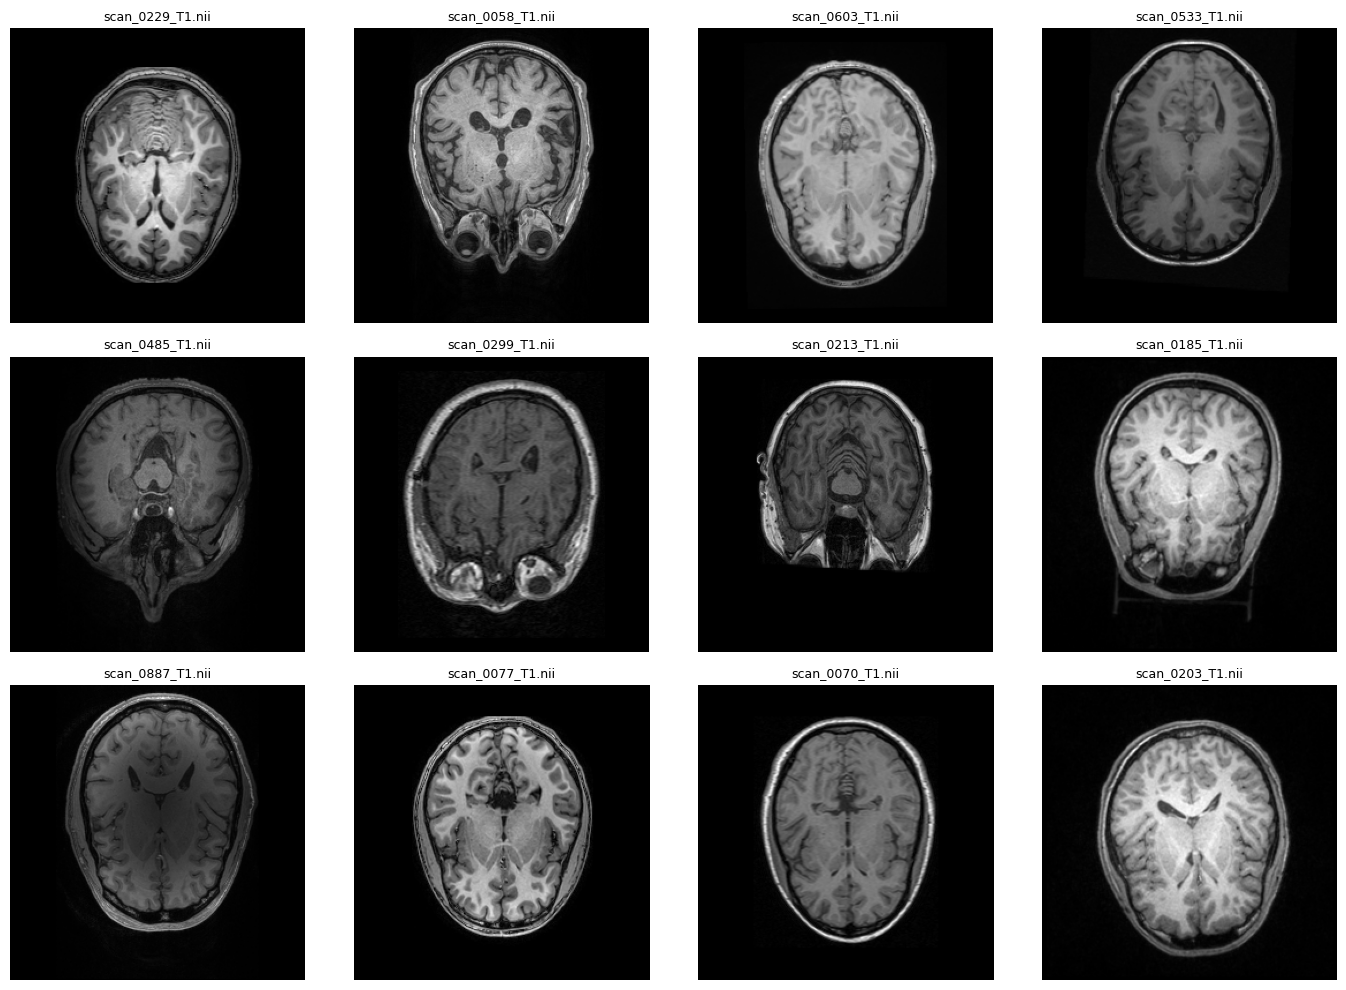

In [20]:
# ============================================================
# Phase 8 - Bias Field Assessment
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

# ------------------------------------------------------------
# Randomly sample 12 T1 images
# ------------------------------------------------------------

random.seed(42)

sample_files = random.sample(
    manifest["T1"].tolist(),
    12
)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, file in zip(axes.ravel(), sample_files):

    img = sitk.ReadImage(
        os.path.join(DATASET_PATH, file)
    )

    arr = sitk.GetArrayFromImage(img)

    mid = arr.shape[0] // 2

    ax.imshow(arr[mid], cmap="gray")

    ax.set_title(file, fontsize=9)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Phase 9 - Foreground / Cropping Assessment
# ============================================================

import os
import random
import numpy as np
import SimpleITK as sitk
import pandas as pd

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

random.seed(42)

samples = random.sample(
    manifest["T1"].tolist(),
    15
)

print("="*60)
print("CROPPING ANALYSIS")
print("="*60)

for file in samples:

    img = sitk.ReadImage(
        os.path.join(DATASET_PATH, file)
    )

    arr = sitk.GetArrayFromImage(img)

    mask = arr > 0

    coords = np.argwhere(mask)

    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0)

    print()

    print(file)

    print("Image Shape :", arr.shape)

    print("Foreground Bounding Box :")

    print(f"Z : {zmin} -> {zmax}")

    print(f"Y : {ymin} -> {ymax}")

    print(f"X : {xmin} -> {xmax}")

CROPPING ANALYSIS

scan_0229_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 39 -> 215
Y : 34 -> 220
X : 56 -> 200

scan_0058_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 0 -> 254
Y : 0 -> 254
X : 40 -> 215

scan_0603_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 43 -> 212
Y : 12 -> 243
X : 40 -> 215

scan_0533_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 4 -> 255
Y : 0 -> 245
X : 33 -> 225

scan_0485_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 0 -> 254
Y : 0 -> 254
X : 40 -> 215

scan_0299_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 28 -> 227
Y : 12 -> 243
X : 38 -> 217

scan_0213_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 28 -> 227
Y : 19 -> 235
X : 51 -> 205

scan_0185_T1.nii
Image Shape : (256, 256, 256)
Foreground Bounding Box :
Z : 40 -> 215
Y : 3 -> 252
X : 3 -> 252

scan_0887_T1.nii
Image Shape : (256, 256, 256)
Foreground Bou

In [22]:
# ============================================================
# Phase 10 - Final Quality Control
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Load reports
# ------------------------------------------------------------

manifest = pd.read_csv(
    os.path.join(METADATA_DIR, "dataset_manifest.csv")
)

validation = pd.read_csv(
    os.path.join(METADATA_DIR, "validation_report.csv")
)

geometry = pd.read_csv(
    os.path.join(METADATA_DIR, "geometry_report.csv")
)

registration = pd.read_csv(
    os.path.join(METADATA_DIR, "registration_report.csv")
)

orientation = pd.read_csv(
    os.path.join(METADATA_DIR, "orientation_report.csv")
)

reorientation = pd.read_csv(
    os.path.join(METADATA_DIR, "reorientation_log.csv")
)

resampling = pd.read_csv(
    os.path.join(METADATA_DIR, "resampling_report.csv")
)

# ------------------------------------------------------------
# QC Summary
# ------------------------------------------------------------

qc = {
    "Total Patients": len(manifest),
    "T1 Images": len(manifest),
    "Lesion Masks": len(manifest),
    "Validated Images": len(validation),
    "Spacing Outlier Patients": resampling["PatientID"].nunique(),
    "Orientation Outlier Patients": reorientation["PatientID"].nunique(),
    "Registration Required": "No",
    "Bias Field Correction": "Skipped",
    "Foreground Cropping": "Skipped"
}

qc_report = pd.DataFrame(
    qc.items(),
    columns=["Metric", "Value"]
)

qc_report.to_csv(
    os.path.join(METADATA_DIR, "qc_report.csv"),
    index=False
)

print("="*60)
print("FINAL QUALITY CONTROL")
print("="*60)

display(qc_report)

print()

print("QC report saved to:")

print(os.path.join(METADATA_DIR, "qc_report.csv"))

FINAL QUALITY CONTROL


,Metric,Value
0,Total Patients,552
1,T1 Images,552
2,Lesion Masks,552
3,Validated Images,1104
4,Spacing Outlier Patients,3
5,Orientation Outlier Patients,10
6,Registration Required,No
7,Bias Field Correction,Skipped
8,Foreground Cropping,Skipped



QC report saved to:
/kaggle/working/preprocessing/metadata/qc_report.csv
